# MedQuAD and MedlinePlus: data understanding

I profile two XML datasets here because they share one problem. Both arrive as XML, both feed the Simplifier, and neither can be read until it is flattened. So I parse both.

| What | Where |
| --- | --- |
| MedQuAD QAPairs, 12 NIH collections | `data/medquad/` |
| MedlinePlus health topics | `data/medlineplus/health_topics/mplus_topics_2026-09-10.xml` |
| MedlinePlus glossary terms | `data/medlineplus/definitions_of_health_terms/` (5 files) |
| Parser, profiler, schema projection | `notebooks/dataset_profile.py` |

Neither dataset has a label, so there is nothing to predict and nothing to correlate a feature against. Class balance and feature-to-label correlation therefore mean nothing here. The rest of the usual pass still applies, and what follows covers column types, missingness, univariate shape, redundancy, duplicates and identifiers, and what each dataset is usable for.

## Dataset shape

Two numbers come before any content. How many files are there, and which tags do they actually use? The parser has to survive what the collections really contain, not what the documentation claims they contain.

In [1]:
# Setup. Run this cell first: it loads the libraries and the shared helper
# module that every other cell in the notebook depends on.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

# Make wide tables readable instead of wrapping them into a jumble.
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 220)

# Python can only import a file from a folder that is on the import path.
# cwd() is the folder this notebook lives in, so add it if it is missing.
notebook_folder = str(Path.cwd())
if notebook_folder not in sys.path:
    sys.path.insert(0, notebook_folder)

# dataset_profile.py holds the XML parsers and the profiling helpers. It is
# imported under the short name dp so the calls below stay readable.
import dataset_profile as dp


In [2]:
# Count the XML files in each of the 12 MedQuAD collection folders.
file_counts = []                          # one entry per collection folder
for collection in dp.MEDQUAD_COLLECTIONS:
    folder = dp.MEDQUAD_DIR / collection
    xml_files = list(folder.glob('*.xml'))    # only files ending in .xml
    file_counts.append({
        'collection': collection,
        'xml_files': len(xml_files),
    })

files_df = pd.DataFrame(file_counts).set_index('collection')
total_files = files_df['xml_files'].sum()

# What share of the whole dataset each folder holds, as a percentage.
files_df['share_pct'] = (files_df['xml_files'] / total_files * 100).round(1)

# MedQuAD removed the answers from three collections for copyright reasons.
# Flag those folders here so their size can be read in context later.
files_df['answers_stripped'] = files_df.index.isin(dp.ANSWER_STRIPPED_COLLECTIONS)

print('MedQuAD XML files in total:', total_files)
files_df.sort_values('xml_files', ascending=False)


MedQuAD XML files in total: 11274


,xml_files,share_pct,answers_stripped
collection,,,
10_MPlus_ADAM_QA,4366,38.7,True
2_GARD_QA,2685,23.8,False
11_MPlusDrugs_QA,1312,11.6,True
3_GHR_QA,1086,9.6,False
4_MPlus_Health_Topics_QA,981,8.7,False
6_NINDS_QA,277,2.5,False
5_NIDDK_QA,157,1.4,False
1_CancerGov_QA,116,1.0,False
12_MPlusHerbsSupplements_QA,99,0.9,True


In [3]:
# Which XML tags does each collection actually use?
#
# dp.medquad_tag_inventory opens a sample of files per collection and counts
# the tags it finds in them.

import textwrap

tags = dp.medquad_tag_inventory(per_collection=25)

# Reshape the counts into a grid: one row per tag, one column per collection.
# fill_value=0 records a tag that never appears as a real 0 instead of a blank.
tag_grid = tags.pivot_table(
    index='tag',
    columns='collection',
    values='count',
    fill_value=0,
)

# A tag counts as "always present" only if it appears in every collection.
present_everywhere = (tag_grid > 0).all(axis=1)
present_at_least_once = (tag_grid > 0).any(axis=1)
always = list(tag_grid.index[present_everywhere])
sometimes = list(tag_grid.index[present_at_least_once & ~present_everywhere])

print(f'{len(tag_grid)} distinct XML tags across {tag_grid.shape[1]} collections')
print(f'present in all of them: {", ".join(always)}')
print()

# textwrap.fill breaks the long tag lists over several lines so the output
# stays inside the screen width and can be read.
print('annotation tags that appear in only some collections:')
for number, collection in enumerate(tag_grid.columns, start=1):
    used_here = [tag for tag in sometimes if tag_grid.loc[tag, collection] > 0]
    if not used_here:
        used_here = ['none']
    wrapped = textwrap.fill(', '.join(used_here), width=74, subsequent_indent=' ' * 8)
    print(f'{number:>2}. {collection}')
    print(f'    {wrapped}')


26 distinct XML tags across 12 collections
present in all of them: Answer, Document, Focus, QAPair, QAPairs, Question

annotation tags that appear in only some collections:
 1. 10_MPlus_ADAM_QA
    CUI, CUIs, Category, FocusAnnotations, SemanticGroup, SemanticType,
        SemanticTypes, Synonym, Synonyms, UMLS
 2. 11_MPlusDrugs_QA
    Category, FocusAnnotations
 3. 12_MPlusHerbsSupplements_QA
    Category, FocusAnnotations
 4. 1_CancerGov_QA
    CUI, CUIs, FocusAnnotations, SemanticGroup, SemanticType, SemanticTypes,
        UMLS
 5. 2_GARD_QA
    CUI, CUIs, FocusAnnotations, SemanticGroup, SemanticType, SemanticTypes,
        Synonym, Synonyms, UMLS
 6. 3_GHR_QA
    CUI, CUIs, FocusAnnotations, SemanticGroup, SemanticType, SemanticTypes,
        Synonym, Synonyms, UMLS
 7. 4_MPlus_Health_Topics_QA
    CUI, CUIs, Category, FocusAnnotations, SemanticGroup, SemanticType,
        SemanticTypes, Synonym, Synonyms, UMLS
 8. 5_NIDDK_QA
    CUI, CUIs, FocusAnnotations, SemanticGroup, Semanti

In [4]:
# The inventory above reads only 25 files per collection. That is not enough to count
# the rare problem: a tag missing from a single file disappears in an aggregate total.
#
# This cell therefore reads all 11,274 XML files. It looks for the modern tag names
# first, then asks the parser what it really returns for every file that comes up empty.

import xml.etree.ElementTree as ET

files_without_modern_pairs = []

for collection in dp.MEDQUAD_COLLECTIONS:
    folder = dp.MEDQUAD_DIR / collection
    for path in sorted(folder.glob('*.xml')):
        root = ET.parse(path).getroot()             # outermost XML element
        pairs = root.findall('QAPairs/QAPair')      # the pairs nested inside
        if len(pairs) == 0:
            files_without_modern_pairs.append((collection, path.name, root.tag))

print(f'files with no pairs under the modern tag names: '
      f'{len(files_without_modern_pairs)} of 11,274')
print()

# Two different causes produce the same symptom, so the tag names alone are not
# enough to tell them apart. Running the parser over each file does separate them:
# a file whose root tag is not <Document> is written in the older lowercase schema,
# which the parser handles, and the rest are ordinary files whose QAPairs block is
# genuinely empty.
print('what the parser returns for each of those files:')
recovered = 0
for collection, file_name, root_tag in files_without_modern_pairs:
    path = dp.MEDQUAD_DIR / collection / file_name
    pairs = dp.parse_medquad_file(path, collection)
    if pairs:
        recovered += 1
    print(f'  {collection}/{file_name}  root=<{root_tag}>  ->  {len(pairs)} pairs')

print()
print(f'files brought back by the legacy schema path: {recovered}')
print(f'files with nothing to extract              : '
      f'{len(files_without_modern_pairs) - recovered}')

files with no pairs under the modern tag names: 10 of 11,274

what the parser returns for each of those files:
  5_NIDDK_QA/0000056.xml  root=<Document>  ->  0 pairs
  5_NIDDK_QA/0000064.xml  root=<Document>  ->  0 pairs
  5_NIDDK_QA/0000065.xml  root=<Document>  ->  0 pairs
  5_NIDDK_QA/0000077.xml  root=<Document>  ->  0 pairs
  5_NIDDK_QA/0000175.xml  root=<Document>  ->  0 pairs
  5_NIDDK_QA/0000177.xml  root=<Document>  ->  0 pairs
  6_NINDS_QA/0000007.xml  root=<doc>  ->  4 pairs
  6_NINDS_QA/0000018.xml  root=<doc>  ->  4 pairs
  6_NINDS_QA/0000182.xml  root=<doc>  ->  4 pairs
  6_NINDS_QA/0000244.xml  root=<doc>  ->  4 pairs

files brought back by the legacy schema path: 4
files with nothing to extract              : 6


MedQuAD has 11,274 XML files across 12 collections. ADAM Medical Encyclopedia and MedlinePlus Drugs account for 5,678 files, about half the total. SeniorHealth has 48.

The files use 26 different XML tags, but only six appear in every collection: `Document`, `Focus`, `QAPairs`, `QAPair`, `Question`, and `Answer`. The other tags vary. `Category` appears only in the four MedlinePlus-derived collections. Some files lack a `UMLS` block, and the `Synonyms` lists run from none to 19 entries. A parser that expects every collection to use the same structure will silently miss data.

I first noticed the problem in a 25-file sample, but that sample couldn't show how often it happened. When I checked all 11,274 files, 10 had no question-answer pairs under the modern tag names.

Four are NINDS files that use an older, lowercase schema. They start with `<doc>` instead of `<Document>` and use tags such as `qaPairs`, `pair`, `question`, and `answer`. These files contain real material, including entries on Holmes-Adie syndrome and ALS. The other six files are from NIDDK. They have a `QAPairs` block, but it is empty, so there are no questions or answers to extract.

Ten files is a small share of the dataset, but the four NINDS files hold content the pipeline would otherwise skip without warning, so the parser now carries a second path for the lowercase schema. It recognises the older element and attribute names and rewrites them in memory, which recovers 16 pairs, four from each file. That brings the total to 47,457. The files on disk are left untouched. Every count from here on includes those 16 pairs. The same pass drops blank annotation values, so the empty `<cui>` element these four files carry does not register as a machine-readable concept.

## Parsing MedQuAD

The parser walks `Document`, then `QAPairs`, then `QAPair`. The meaning lives in the attributes (`qid`, `qtype`, `pid`), not in the text, so it reads those out and flattens every pair into one table.

In [5]:
# Parse all 11,274 MedQuAD files into one table.
#
# dp.load_medquad() walks Document -> QAPairs -> QAPair inside each file and
# returns a table with one row per question-answer pair. The values come from
# the XML attributes (qid, qtype, pid) as well as from the text elements, and
# a few extra columns are derived, such as word and character counts.

medquad = dp.load_medquad()

print('rows (question-answer pairs):', medquad.shape[0])
print('columns                     :', medquad.shape[1])
print()
print('the first three rows:')
medquad.head(3)


  1_CancerGov_QA: 116 files
  2_GARD_QA: 2685 files
  3_GHR_QA: 1086 files
  4_MPlus_Health_Topics_QA: 981 files
  5_NIDDK_QA: 157 files
  6_NINDS_QA: 277 files
  7_SeniorHealth_QA: 48 files
  8_NHLBI_QA_XML: 88 files
  9_CDC_QA: 59 files
  10_MPlus_ADAM_QA: 4366 files
  11_MPlusDrugs_QA: 1312 files
  12_MPlusHerbsSupplements_QA: 99 files
MedQuAD parsed in 2.7s -> 47,457 QAPairs
rows (question-answer pairs): 47457
columns                     : 23

the first three rows:


,qa_uid,doc_id,collection,source,url,focus,focus_category,qtype,pid,qid,...,answer_chars,answer_words,question_words,has_umls,n_cuis,first_cui,semantic_group,n_semantic_types,n_synonyms,file
0,1_CancerGov_QA/0000001_1-1,0000001_1,1_CancerGov_QA,CancerGov,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,Adult Acute Lymphoblastic Leukemia,,information,1,0000001_1-1,...,2682,436,8,True,1,C0751606,Disorders,1,0,0000001_1.xml
1,1_CancerGov_QA/0000001_1-2,0000001_1,1_CancerGov_QA,CancerGov,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,Adult Acute Lymphoblastic Leukemia,,symptoms,2,0000001_1-2,...,717,127,10,True,1,C0751606,Disorders,1,0,0000001_1.xml
2,1_CancerGov_QA/0000001_1-3,0000001_1,1_CancerGov_QA,CancerGov,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,Adult Acute Lymphoblastic Leukemia,,exams and tests,3,0000001_1-3,...,2481,445,8,True,1,C0751606,Disorders,1,0,0000001_1.xml


In [6]:
# dp.classify_columns looks at the values in a column and sorts it into a
# rough type: identifier, nominal, numeric, boolean, or free text.
#
# The id_columns argument names the join keys, so they are labelled
# 'identifier' rather than being mistaken for numbers.

column_types = dp.classify_columns(
    medquad,
    id_columns=['qa_uid', 'doc_id', 'qid'],
)
column_types


,column,dtype,course_type,n_unique,pct_missing
0,qa_uid,object,"id (join key, never a feature)",47423,0.0
1,doc_id,object,"id (join key, never a feature)",5404,0.0
2,collection,object,nominal,12,0.0
3,source,object,nominal,12,0.0
4,url,object,nominal (free text),11258,0.0
5,focus,object,nominal (free text),10542,0.0
6,focus_category,object,nominal,4,0.0
7,qtype,object,nominal,39,0.0
8,pid,object,nominal,41,0.0
9,qid,object,"id (join key, never a feature)",30086,0.0


### Reading the column classification

The parse gives 12 fields straight out of the XML (`doc_id`, `collection`, `source`, `url`, `focus`, `focus_category`, `qtype`, `pid`, `qid`, `question`, `answer`, plus the file name) and 11 more that the profiler derives from them: lengths, UMLS flags, synonym counts, and the `qa_uid` key.

Three of them matter beyond this notebook, because their type decides what happens to them later.

- `qtype` is nominal with dozens of levels. If it is ever used as a feature it has to be one-hot encoded. It should never be fed in as an integer, since the order the type strings happen to sit in is an artifact of the file layout.
- `qid` and `pid` look numeric in places, but one is an identifier and the other is a position. They are join keys, not to be used as part of the features. Putting a `qid` in a feature matrix would leak document structure and act as a fake perfect predictor.
- `n_cuis` and `n_semantic_types` are small integers, and the order means nothing here. They are counts to handle carefully, not magnitudes to feed straight in.

`focus_category` is nominal too, and it is the one most likely to be misread. It holds `Disease`, `Drug`, or `Other` in the four MedlinePlus-derived collections, and it is blank everywhere else.

## Missingness


In [7]:
# How much of each column is empty?
#
# dp.missingness counts the blanks per column and works out what share of the
# table that is. The 'blank_or_empty' column is the one to read: it counts cells
# holding an empty string, and isna() reports nothing missing in this table.

missing_table = dp.missingness(medquad)

# The same table as a single number, so the total quoted in the prose below can
# be checked against this cell instead of taken on trust. It moves whenever the
# parse changes, so it is worth printing rather than quoting from memory.
print('empty-string cells in the whole table:',
      f"{missing_table['blank_or_empty'].sum():,}")

missing_table

empty-string cells in the whole table: 78,580


,missing,missing_pct,blank_or_empty
doc_id,0,0.0,5
focus,0,0.0,14
focus_category,0,0.0,15447
answer,0,0.0,31034
first_cui,0,0.0,16040
semantic_group,0,0.0,16040


One warning first. Every blank in this table is an empty string, not a null. `isna()` returns zero for all three datasets, while 78,580 cells in MedQuAD hold empty text. A missingness check written the obvious way would report that nothing is missing here. That is how these blanks nearly escaped notice, and it is why the profiler counts empty strings and why `blank_or_empty` is the column to read.

The empty answers are the biggest thing in the table. 31,034 of 47,457 pairs have no answer text, 65% of the dataset. The cause is documented rather than guessed. MedQuAD's own readme says it removed the answers from three collections to respect the MedlinePlus copyright. It names them: ADAM Medical Encyclopedia, MedlinePlus Drug information, and MedlinePlus Herbal medicine and supplement information. Those three supply 31,029 of the 31,034 blanks.

The remaining 5 sit in GARD, and they are a separate problem. MedQuAD never touched that collection, and its other 5,389 pairs all carry answers. So the five are a defect in the source rather than a policy. All of them are `information` questions, about Emery-Dreifuss muscular dystrophy in two forms, Familial HDL deficiency, HELLP syndrome, and X-linked lymphoproliferative syndrome. Each one still carries its NLM URL, which makes me read them as an export glitch rather than a deletion.

The blanks are systematic rather than scattered, which rules out imputation. Filling 65% of a column by mode or median would manufacture text that no source supports. The Verifier compares generated claims against retrieved passages, so an invented passage passes that comparison. An invented answer is therefore a failure the pipeline cannot catch on its own. The decision is to exclude these rows from retrieval, which costs less than 65% suggests. The withheld pairs come from an encyclopedia and a drug monograph set, not the plain-language prose the Simplifier needs.

Everything else in the table is structural rather than missing. `focus_category` is blank for 15,447 pairs, and those are exactly the pairs outside the four MedlinePlus-derived collections. 32,010 rows sit inside those collections, and not one of them is blank. The readme says why. MedQuAD annotated the focus category only in those four collections, so the field never applied to the other eight.

The UMLS block behaves the same way. `first_cui` and `semantic_group` are blank for 16,040 pairs. Those are exactly the pairs whose `has_umls` is False, with no exception in either direction. The blank means "not annotated" rather than "unknown", and it doubles as a collection label. All 12,889 of the blank rows are in Drugs, all 792 in Herbs, 1,778 of 17,348 in ADAM, 295 of 981 in Health Topics, all 270 in CDC, and 16 in the four NINDS files that ship in the older schema. Those four files carry an empty `<cui>` element rather than no element at all, which is why the parser drops blank values before deciding whether a row is annotated.

Three smaller gaps reach the retrieval file, so they need decisions rather than notes. Fourteen pairs have an empty `focus`, all in CDC. Four of those also carry a question that never got filled in, reading "What is (are) ?", "Who is at risk for ? ?" or "How to prevent ?"; the other ten read normally and simply had no focus on the page. All 14 leave a retrieval document with a blank `title` to key on. One MedlinePlus topic, Rotator Cuff Injuries, has an empty summary while its URL, 25 links, and 2 topic groups are all present. 33 of the 97 glossary rows carry no reference URL, 21 of them in the nutrition and general-health files.

The reason not to impute differs by column. A blank answer is the payload, so inventing it would fabricate medical text. A blank category or CUI is an annotation the source never made. Filling it in would assert something no one said, and a wrong CUI would point at the wrong concept. The blanks also carry information as they stand, because they tell you which collection a row came from. A mode fill would erase that.

So the decisions are short. Exclude the answer-less rows from retrieval. Leave the annotation blanks as blanks. Exclude Rotator Cuff Injuries from the index. Let the 14 CDC documents keep a blank title and match them on `text` instead. Accept the 33 glossary rows as definitions without a citation, which matters only to the Verifier.

## Composition by collection


In [8]:
# One row per collection, with the number of pairs and the number of usable
# answers side by side. This is what shows that the largest collections hold
# the least usable text.

per_collection = dp.medquad_by_collection(medquad)
per_collection


,files,qapairs,unique_qids,focus_terms,question_types,answers_present,pct_answer_missing,median_answer_words,max_answer_words
collection,,,,,,,,,
10_MPlus_ADAM_QA,4366,17348,17348,4362,14,0,100.00,0.0,0
11_MPlusDrugs_QA,1312,12889,12889,1312,18,0,100.00,0.0,0
3_GHR_QA,1086,5430,5430,1086,5,5430,0.00,85.0,731
2_GARD_QA,2685,5394,5394,2685,6,5389,0.09,170.0,1278
5_NIDDK_QA,151,1192,1192,148,12,1192,0.00,171.0,2024
6_NINDS_QA,277,1104,1104,276,5,1104,0.00,72.0,529
4_MPlus_Health_Topics_QA,981,981,981,981,1,981,0.00,146.0,284
12_MPlusHerbsSupplements_QA,99,792,792,99,8,0,100.00,0.0,0
7_SeniorHealth_QA,48,769,769,48,13,769,0.00,132.0,1931


What is on disk is not what I can retrieve from. ADAM and Drugs hold 30,237 of the 47,457 pairs, 64% of the rows, and they carry no usable answers at all. Herbs and Supplements adds another 792. Take those three out and 16,423 pairs remain, 35% of the folder. Even that is uneven. GHR and GARD alone supply 10,819 of them, two thirds of the usable total.

Two collection-level details matter later.

- `4_MPlus_Health_Topics_QA` uses exactly one question type across all 981 files. Those rows are topic summaries with a boilerplate question attached, not a real question-answer exchange, so they will behave differently in retrieval from a genuine pair, and differently again in any prompt that expects a question.
- `1_CancerGov_QA` reports 729 pairs but only 695 unique question IDs. Something repeats inside it, and the identifier section further down works out what.

## Sampling

MedQuAD ships as a census of 12 collections rather than a sample of one, so there is nothing to sample at this stage. It is still worth running the check, because it shows what a uniform draw would hand back.

In [9]:
# What would a plain random draw from the table hand back?
#
# 200 rows are picked at random, with no regard for which collection they come
# from. random_state=42 makes the draw repeatable: the same seed always gives
# the same 200 rows, so the numbers below do not change between runs.

random_draw = medquad.sample(200, random_state=42)

print('A uniform random 200-pair draw from MedQuAD, by collection:')
print(random_draw['collection'].value_counts().to_string())
print()

# 'answer_missing' is True when the answer text is empty, so comparing it to
# False counts the rows that do carry text.
rows_with_text = (random_draw['answer_missing'] == False).sum()
print('pairs in that draw carrying answer text:', int(rows_with_text), 'of 200')

# On a True/False column, .mean() gives the share that is True.
print('share of the draw that is unusable     :',
      f'{random_draw["answer_missing"].mean() * 100:.0f}%')


A uniform random 200-pair draw from MedQuAD, by collection:
collection
10_MPlus_ADAM_QA               81
11_MPlusDrugs_QA               41
2_GARD_QA                      29
3_GHR_QA                       27
4_MPlus_Health_Topics_QA        6
7_SeniorHealth_QA               5
8_NHLBI_QA_XML                  3
9_CDC_QA                        2
6_NINDS_QA                      2
12_MPlusHerbsSupplements_QA     2
5_NIDDK_QA                      2

pairs in that draw carrying answer text: 76 of 200
share of the draw that is unusable     : 62%


The answer-less collections dominate by row count, so a uniform sample inherits their share and spends roughly two thirds of its budget on rows with no text. Any sample I draw for the Simplifier's example sets therefore has to be stratified by collection and taken only from the answer-bearing rows. That is what the usable subset below is.

## Univariate shape


usable QAPairs: 16,423 of 47,457 (34.6%)


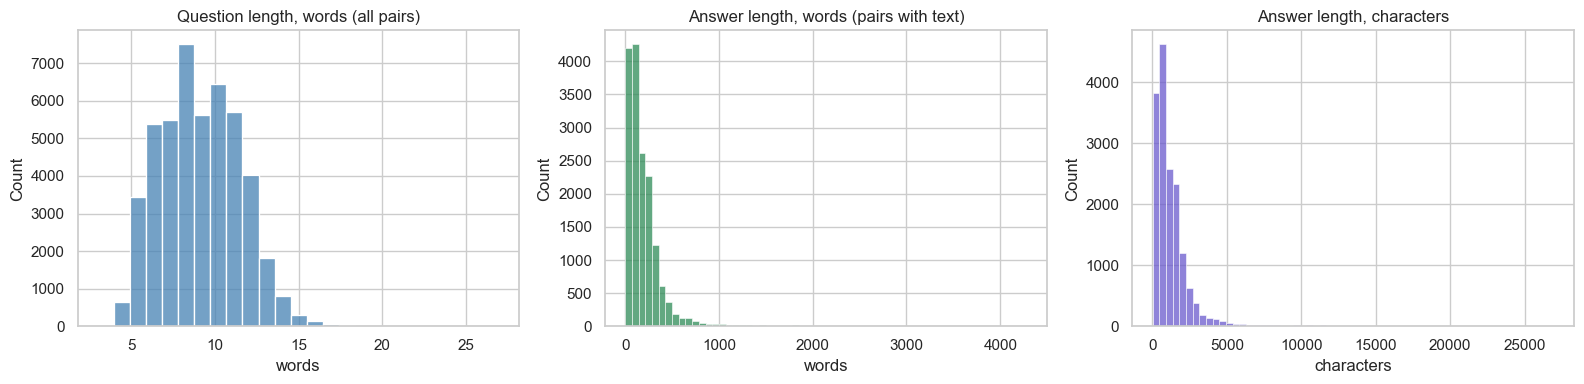

,question_words,answer_words,answer_chars
count,16423.0,16423.0,16423.0
mean,8.2,201.3,1267.2
std,2.4,248.4,1529.1
min,3.0,1.0,6.0
25%,6.0,71.0,479.0
50%,8.0,138.0,878.0
75%,10.0,252.0,1568.5
max,27.0,4281.0,26976.0


In [10]:
# Restrict everything from here on to the pairs that actually carry an answer.
#
# 'answer_missing' is True for 65% of the rows, so the filter is spelled out
# in full: keep the rows where the answer is present.
#
# .copy() makes this a separate table, so changing it later is safe and raises
# no warnings from pandas.

has_answer = medquad['answer_missing'] == False
usable = medquad[has_answer].copy()

print(f'usable QAPairs: {len(usable):,} of {len(medquad):,} '
      f'({len(usable) / len(medquad) * 100:.1f}%)')

# Three histograms side by side, showing the shape of both text lengths.
# A histogram sorts values into buckets and draws one bar per bucket, so the
# overall shape is visible at a glance.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(medquad['question_words'], bins=25, ax=axes[0], color='steelblue')
axes[0].set_title('Question length, words (all pairs)')
axes[0].set_xlabel('words')

sns.histplot(usable['answer_words'], bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('Answer length, words (pairs with text)')
axes[1].set_xlabel('words')

sns.histplot(usable['answer_chars'], bins=60, ax=axes[2], color='slateblue')
axes[2].set_title('Answer length, characters')
axes[2].set_xlabel('characters')

plt.tight_layout()
plt.show()

# The same three columns as numbers: count, mean, quartiles, minimum, maximum.
usable[['question_words', 'answer_words', 'answer_chars']].describe().round(1)


Question length is tight. Across all 47,457 pairs the mean is 8.9 words, the maximum is 27, and the skew is 0.32. That is the shape I want for a retrieval query, because question length will not confound anything when the Simplifier builds a query out of a clinical concept.

Answer length, on the 16,423 rows that carry text, is the opposite. The mean is 201 words against a median of 138, the maximum is 4,281, and the skew runs above 5. A mean that far above the median is the signature of a long right tail, and that is what this is: a handful of encyclopedia-length entries sharing a column with one-line answers. Since this dataset is retrieval material rather than a training matrix, the consequence is not a modelling problem but a chunking problem. A 4,281-word passage has to be split before it is embedded, and the splitter has to respect sentence and section boundaries, or retrieval will hand back half a fact.

The question-length distribution doubles as a parse check. If the `Question` element had been read wrong, the counts would show flat or bimodal noise instead of one tight peak.

## Outliers


IQR fence at k=2 flags 629 rows (3.83%)
99th percentile answer length: 1278 words
rows above the 99th percentile: 165


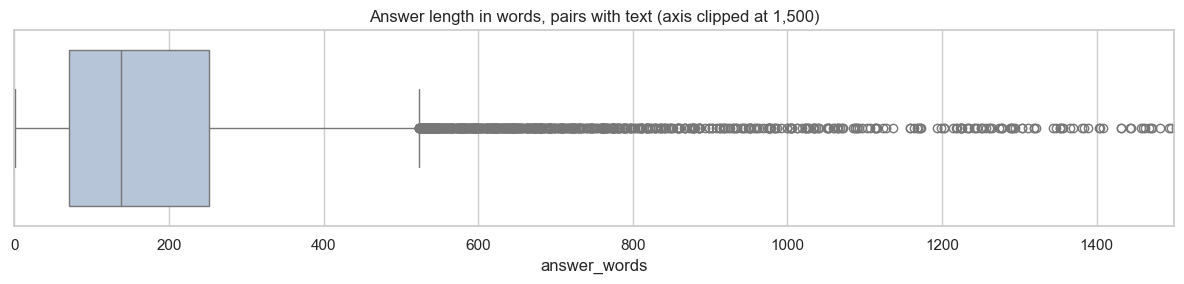

,collection,focus,qtype,answer_words
549,1_CancerGov_QA,Breast Cancer,treatment,4281
85,1_CancerGov_QA,Childhood Soft Tissue Sarcoma,treatment,3708
86,1_CancerGov_QA,Childhood Vascular Tumors,information,3692
16080,8_NHLBI_QA_XML,Sickle Cell Disease,treatment,3594
77,1_CancerGov_QA,Childhood Rhabdomyosarcoma,treatment,3461


In [11]:
# Outlier check on answer length.
#
# The rule is the interquartile range (IQR): find the middle 50% of the values,
# measure how wide that band is, then flag anything further than k times the
# band above or below it. Here k = 2.
#
# A second, simpler rule is shown next to it: the top 1% of lengths.

answer_words = usable['answer_words']

outlier_rows = dp.iqr_outlier_mask(answer_words, k=2)
number_flagged = int(outlier_rows.sum())
share_flagged = outlier_rows.mean() * 100

cutoff_99 = answer_words.quantile(0.99)
rows_above_99 = int((answer_words > cutoff_99).sum())

print(f'IQR fence at k=2 flags {number_flagged:,} rows ({share_flagged:.2f}%)')
print(f'99th percentile answer length: {cutoff_99:.0f} words')
print(f'rows above the 99th percentile: {rows_above_99:,}')

# A box plot shows the same thing as a picture. The box is the middle half of
# the values, the line inside it is the median, and the points beyond it are
# the long tail. The axis is clipped at 1,500 words, otherwise the few very
# long answers squash the box flat.
fig, ax = plt.subplots(figsize=(12, 3))
sns.boxplot(x=answer_words, ax=ax, color='lightsteelblue')
ax.set_xlim(0, 1500)
ax.set_title('Answer length in words, pairs with text (axis clipped at 1,500)')
plt.tight_layout()
plt.show()

# What is actually in the tail? The five longest answers, with their source.
usable.nlargest(5, 'answer_words')[['collection', 'focus', 'qtype', 'answer_words']]


At k = 2 the IQR fence runs from -291 words to 614, so in practice it only ever catches the right tail. It flags 629 rows, 3.8% of the answer-bearing pairs. Calling nearly 4% of a dataset an outlier is too many to act on, and the reason is the shape of the distribution rather than a cluster of errors. A long tail pushes the fence out, so the fence ends up catching the tail itself instead of the few bad rows it is meant to isolate.

Deleting them would also be the wrong move. The longest entries are the most complete NIH summaries in the collection, which is exactly what the Simplifier needs, so they should be kept and chunked. Winsorizing a 4,281-word encyclopedia entry down to a few hundred words would destroy the facts it exists to carry.

If a 1% cut is wanted instead, it lands at 1,278 words and separates 165 rows. Either way, the number that matters for the index is not how many rows are extreme but how the extreme rows get split.

The five longest rows are printed above as a check on what the tail actually holds.

## Redundancy between features


In [12]:
# Correlation between the numeric columns.
#
# Pearson correlation measures how close two columns sit to a straight line.
# +1 means they rise and fall together, -1 means one rises as the other falls,
# and 0 means there is no straight-line relationship between them. A value near
# +1 or -1 means one of the two columns is redundant.
#
# Only numeric columns can be compared this way, so they are listed by name
# first.

numeric_columns = [
    'question_words',
    'answer_words',
    'answer_chars',
    'n_cuis',
    'n_semantic_types',
    'n_synonyms',
]

print('Pearson correlation, numeric columns:')
print(usable[numeric_columns].corr(method='pearson').round(2).to_string())


Pearson correlation, numeric columns:
                  question_words  answer_words  answer_chars  n_cuis  n_semantic_types  n_synonyms
question_words              1.00          0.05          0.05    0.22              0.13        0.03
answer_words                0.05          1.00          1.00    0.06             -0.01       -0.16
answer_chars                0.05          1.00          1.00    0.05             -0.01       -0.14
n_cuis                      0.22          0.06          0.05    1.00              0.59        0.05
n_semantic_types            0.13         -0.01         -0.01    0.59              1.00        0.13
n_synonyms                  0.03         -0.16         -0.14    0.05              0.13        1.00


In [13]:
# Pearson only sees straight-line relationships, so it can report 0 for a
# relationship that is real but curved. Mutual information makes no assumption
# about shape, so the two columns are read together.
#
# Mutual information is slower to compute, so it runs on a 6,000-row sample
# rather than the whole table. The values are not exact, but they are stable.

from sklearn.feature_selection import mutual_info_regression

sample = usable.sample(6000, random_state=0)

results = []
for column in ['question_words', 'n_cuis', 'n_semantic_types', 'n_synonyms']:
    # How strongly does this column move with answer length, in a straight line?
    pearson_r = sample[column].corr(sample['answer_words'])

    # How much does knowing this column tell us about answer length, whatever
    # the shape of the relationship? Higher means more information.
    # The input column is passed as a one-column table, and [0] takes the
    # single number back out of the list that comes back.
    mutual_information = mutual_info_regression(
        sample[[column]],
        sample['answer_words'],
        random_state=0,
    )[0]

    results.append({
        'feature': column,
        'pearson_r': round(pearson_r, 3),
        'mutual_information': round(mutual_information, 3),
    })

pd.DataFrame(results)


,feature,pearson_r,mutual_information
0,question_words,0.047,0.105
1,n_cuis,0.055,0.000
2,n_semantic_types,-0.016,0.006
3,n_synonyms,-0.157,0.074


With no label to correlate against, the bivariate pass does the two jobs left to it. It finds redundant pairs, and it checks whether a weak linear relationship is hiding a real one.

`answer_words` and `answer_chars` move together almost perfectly. That is expected, and it means only one of the two should ever enter a feature set.

`question_words` against `answer_words` is the more interesting pair. Pearson alone would write it off, since Pearson only sees linear association. Mutual information is the check. If the MI value sits clearly above what an unrelated pair produces, the relationship is real even when r is near zero. Reading the two columns side by side is the honest version of this check.

## Question types and coverage


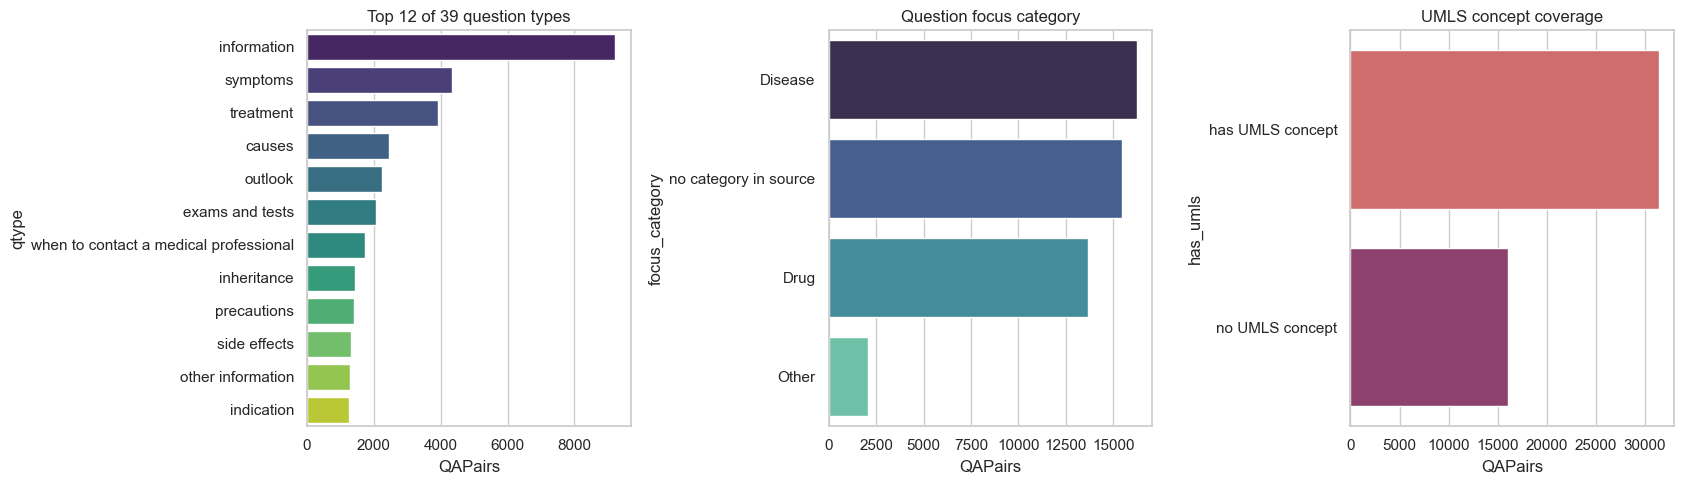

rows per collection:
collection
10_MPlus_ADAM_QA               17348
11_MPlusDrugs_QA               12889
3_GHR_QA                        5430
2_GARD_QA                       5394
5_NIDDK_QA                      1192
6_NINDS_QA                      1104
4_MPlus_Health_Topics_QA         981
12_MPlusHerbsSupplements_QA      792
7_SeniorHealth_QA                769
1_CancerGov_QA                   729
8_NHLBI_QA_XML                   559
9_CDC_QA                         270

unique focus entities whole dataset : 10541
unique focus entities with answers : 5129
unique question texts              : 44619


In [14]:
# Three charts: question type, focus category, and UMLS coverage.

number_of_types = medquad['qtype'].nunique()

# A blank focus category is not missing data. It means the source file carried
# no category, so it is relabelled to say so before it is plotted.
focus_categories = medquad['focus_category'].replace('', 'no category in source')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: the twelve most common question types.
type_counts = medquad['qtype'].value_counts().head(12)
sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[0],
            hue=type_counts.index, palette='viridis', legend=False)
axes[0].set_title(f'Top 12 of {number_of_types} question types')
axes[0].set_xlabel('QAPairs')

# Panel 2: how many pairs fall into each focus category.
category_counts = focus_categories.value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[1],
            hue=category_counts.index, palette='mako', legend=False)
axes[1].set_title('Question focus category')
axes[1].set_xlabel('QAPairs')

# Panel 3: does the row carry a UMLS concept, yes or no?
# 'has_umls' is True/False, which makes a poor axis label, so it is mapped to
# readable text first.
umls_labels = medquad['has_umls'].map({True: 'has UMLS concept',
                                       False: 'no UMLS concept'})
umls_counts = umls_labels.value_counts()
sns.barplot(x=umls_counts.values, y=umls_counts.index, ax=axes[2],
            hue=umls_counts.index, palette='flare', legend=False)
axes[2].set_title('UMLS concept coverage')
axes[2].set_xlabel('QAPairs')

plt.tight_layout()
plt.show()

# The counts behind the first panel.
print('rows per collection:')
print(medquad['collection'].value_counts().to_string())
print()

# nunique() counts distinct values, so these answer "how many different
# conditions are written about?" and not "how many rows are there?".
#
# The 14 rows with an empty focus are dropped first. An empty string is not a
# condition, and keeping it would report one more term than exists.
named_focus = medquad.loc[medquad['focus'] != '', 'focus']
usable_named_focus = usable.loc[usable['focus'] != '', 'focus']

print('unique focus entities whole dataset :', named_focus.nunique())
print('unique focus entities with answers :', usable_named_focus.nunique())
print('unique question texts              :', medquad['question'].nunique())

Question type is the strongest structural signal in the dataset. There are 39 types. `information` alone is 19% of the dataset, and the top six (`information`, `symptoms`, `treatment`, `causes`, `outlook`, `exams and tests`) account for 51% of all rows.

The usable subset reorders them, and the reordering is the finding. Remove the three answer-less collections and `information` still leads at 4,539 rows, but `symptoms` and `treatment` follow, and the next three are `inheritance`, `frequency`, and `genetic changes`. Those three are rare-disease categories, and they climb because GARD and GHR supply two thirds of the usable text. So the text that actually gets indexed leans toward rare inherited conditions and away from common ones and medications. I would flag that as a coverage gap. This dataset lines up well with explaining a rare diagnosis, and it is thin on the medication and everyday-condition questions a general patient is most likely to ask.

UMLS coverage reaches 31,417 rows, 66% of the dataset, so the medical entity is machine-readable for most of it. The Extractor can use that later, and it is why the CUIs stay as columns even though they are not retrieval text.

The focus counts carry a warning for the duplicate check that follows. There are 10,541 distinct focus entities across the dataset, but only 5,129 of them survive in the usable subset, because the same conditions get described in more than one collection. The count ignores the 14 rows with an empty focus, since an empty string is not a condition.

## Identifiers and duplicate records


In [15]:
# Is (collection, qid) a safe key for a single row?
#
# duplicated() normally marks only the extra copies. keep=False marks every row
# that takes part in a repeat, so both sides of each collision are shown below.

duplicate_keys = medquad[medquad.duplicated(subset=['collection', 'qid'], keep=False)]

print('rows sharing a (collection, qid) key:', len(duplicate_keys))
print(duplicate_keys['collection'].value_counts().to_string())
print()

# Three row counts side by side show the size of the problem.
total_rows = len(medquad)
unique_uids = medquad['qa_uid'].nunique()
unique_collection_qid = medquad[['collection', 'qid']].drop_duplicates().shape[0]

print('rows                   :', total_rows)
print('unique qa_uid          :', unique_uids)
print('unique (collection,qid):', unique_collection_qid)
print()

# Print the colliding rows together with the columns that tell them apart.
print('duplicate key rows, with the columns that distinguish them:')
print(duplicate_keys[['collection', 'qid', 'pid', 'focus', 'file']]
      .sort_values('qid')
      .head(12)
      .to_string(index=False))


rows sharing a (collection, qid) key: 42
collection
1_CancerGov_QA    42

rows                   : 47457
unique qa_uid          : 47423
unique (collection,qid): 47423

duplicate key rows, with the columns that distinguish them:
    collection         qid pid                                focus            file
1_CancerGov_QA 0000013_2-1   1 Chronic Myeloproliferative Neoplasms   0000013_2.xml
1_CancerGov_QA 0000013_2-1   1         Chronic Myelogenous Leukemia 0000013_2_6.xml
1_CancerGov_QA 0000013_2-1   1                    Polycythemia Vera 0000013_2_1.xml
1_CancerGov_QA 0000013_2-1   1        Chronic Eosinophilic Leukemia 0000013_2_5.xml
1_CancerGov_QA 0000013_2-1   1                Primary Myelofibrosis 0000013_2_2.xml
1_CancerGov_QA 0000013_2-1   1        Chronic Neutrophilic Leukemia 0000013_2_4.xml
1_CancerGov_QA 0000013_2-1   1            Essential Thrombocythemia 0000013_2_3.xml
1_CancerGov_QA 0000013_2-2   2 Chronic Myeloproliferative Neoplasms   0000013_2.xml
1_CancerGov_QA 0

In [16]:
# Is the same answer text reused across rows?
#
# The check compares exact text, so a passage that was lightly edited counts as
# new text and is not flagged. That makes this a lower bound.
#
# .str.strip() removes leading and trailing spaces first, so that a stray space
# does not make two identical passages look different.

non_empty = usable[usable['answer'].str.strip() != '']

# keep=False keeps every row in a repeat group, not only the extra copies.
repeated = non_empty[non_empty.duplicated(subset=['answer'], keep=False)]

# Group the repeated rows by their text and count how large each group is,
# largest first.
group_sizes = repeated.groupby('answer').size().sort_values(ascending=False)

# For each repeated passage, how many different collections is it used in?
collections_per_text = repeated.groupby('answer')['collection'].nunique()

print('non-empty answers                    :', f'{len(non_empty):,}')
print('rows whose answer text is not unique :', len(repeated),
      f'({len(repeated) / len(non_empty) * 100:.2f}%)')
print('distinct passages that repeat        :', len(group_sizes))
print('repeated passages in more than one collection:',
      int((collections_per_text > 1).sum()))
print()

# Only the first 70 characters of each passage are printed, so the output stays
# readable and one long answer cannot flood the cell.
print('largest repeat groups, in rows (text truncated):')
for text, count in group_sizes.head(5).items():
    print(f'  {count:>4} rows | {text[:70]}...')
print()

print('collections holding repeated answer text:')
print(repeated['collection'].value_counts().to_string())
print()

# Follow the single largest repeated passage and see where it was used.
biggest_group_text = group_sizes.index[0]
rows_using_it = non_empty[non_empty['answer'] == biggest_group_text]

print('the largest group, one row per condition it is attached to:')
print(rows_using_it[['collection', 'focus']].head(8).to_string(index=False))
print('rows in this group:', len(rows_using_it),
      '| collections:', rows_using_it['collection'].nunique())
print('text:', biggest_group_text[:300], '...')


non-empty answers                    : 16,423
rows whose answer text is not unique : 683 (4.16%)
distinct passages that repeat        : 85
repeated passages in more than one collection: 0

largest repeat groups, in rows (text truncated):
   348 rows | This condition is inherited in an autosomal recessive pattern, which m...
    70 rows | This condition is inherited in an autosomal dominant pattern, which me...
    25 rows | New types of treatment are being tested in clinical trials. Informatio...
    12 rows | This condition is inherited in an X-linked recessive pattern. The gene...
     8 rows | This condition is inherited in an autosomal dominant pattern, which me...

collections holding repeated answer text:
collection
3_GHR_QA          465
5_NIDDK_QA         96
2_GARD_QA          73
1_CancerGov_QA     33
9_CDC_QA           12
6_NINDS_QA          4

the largest group, one row per condition it is attached to:
collection                                        focus
  3_GHR_QA         

The identifier check passes with one exception. There are 47,457 rows against 47,423 unique `qa_uid` values, so 34 rows are surplus. The cell counts 42 rows sharing a key, which is that surplus plus the first row of each of the eight repeated groups. All of them sit in `1_CancerGov_QA`, which is also why that collection showed 729 pairs against 695 unique question IDs.

One question under two document IDs is what I assumed at first, and it is not what is happening. CancerGov ships one topic as a parent file plus a file per subtype, and every sibling carries the same `id` attribute and reuses the parent's question numbers while describing a different condition. `0000013_2` appears in seven files covering seven myeloproliferative conditions, `0000013_3` in five files covering five more, and the eight repeated keys sit entirely inside those two. The 42 rows involved span 12 files and 12 conditions.

That also kills the obvious fix. Adding `doc_id` to the key changes nothing, because the colliding rows already share a `doc_id`: `collection + doc_id + qid` still gives 47,423 unique keys, and only `collection + file + qid` gives all 47,457. The fix belongs in the flattening step, not in a notebook further down the line. It is tempting to wave away 34 rows out of 47,000. The projection cell further down shows why that fails: it reports 16,423 MedQuAD documents against 16,389 unique keys, those same 34 rows reappearing as duplicate identifiers in the artifact the index actually consumes.

The duplicate-text check turned up something more specific than I expected. Of the 16,423 non-empty answers, 683 repeat text that appears elsewhere, 4.16%. Those 683 rows collapse to 85 distinct passages, and not one of those passages crosses a collection boundary.

What is happening instead is worse for retrieval, in a narrower way. The largest repeat group is not disease content at all. The standard autosomal-recessive inheritance sentence, the one explaining that both parents carry a copy of the mutated gene, appears 348 times, attached to 348 different diseases in GHR. Its autosomal-dominant counterpart follows at 70, then 25, 12, and 8. A boilerplate passage repeated hundreds of times takes hundreds of slots in the index, and a query about any of those 348 diseases can pull it back ahead of the text that actually describes the disease. Deduplicating on exact answer text before embedding is not housekeeping, then. It is what stops one generic paragraph from becoming the most retrievable text in the dataset.

## Reading rows by hand

Counts hide register and formatting. The next two cells print one pair from every collection that carries answers, then pin down the artifacts a random draw only sometimes surfaces.

In [17]:
# Counts hide how the text is actually written, so print one real pair from
# every collection that carries answers and read it.
#
# groupby('collection').sample(n=1) picks one row from each group.
# group_keys=False stops pandas adding an extra index level, which keeps the
# loop below simple.

one_per_collection = usable.groupby('collection', group_keys=False).sample(
    n=1,
    random_state=7,
)

for index, row in one_per_collection.iterrows():
    print('=' * 96)
    print('collection:', row['collection'],
          '| focus:', row['focus'],
          '| qtype:', row['qtype'])
    print('Q:', row['question'])
    print('A:', row['answer'][:400], '...')

collection: 1_CancerGov_QA | focus: Small Intestine Cancer | qtype: stages
Q: What are the stages of Small Intestine Cancer ?
A: Key Points - Tests and procedures to stage small intestine cancer are usually done at the same time as diagnosis. - There are three ways that cancer spreads in the body. - Cancer may spread from where it began to other parts of the body. - Small intestine cancer is grouped according to whether or not the tumor can be completely removed by surgery. Tests and procedures to stage small intestine canc ...
collection: 2_GARD_QA | focus: Afibrinogenemia | qtype: treatment
Q: What are the treatments for Afibrinogenemia ?
A: How might afibrinogenemia be treated? There is no known prevention or cure for afibrinogenemia. To treat bleeding episodes or to prepare for surgery to treat other conditions, patients may receive: The liquid portion of the blood (plasma) A blood product containing concentrated fibrinogen (cryoprecipitate) through a vein (transfusion) Prophylacti

In [18]:
# Four specific things a random draw only sometimes reveals. Searching the
# whole table for them turns "I saw this once" into a number.

# 1. Accented characters lost in the export: 'Español' comes back as 'Espaol'.
#    regex=False means the search text is treated as plain text, not a pattern.
mojibake = usable[usable['answer'].str.contains('Espaol', regex=False)]
print('answers with the mangled word "Espaol" where the source had an accent:',
      len(mojibake))
print('collections affected:', mojibake['collection'].unique().tolist())
print()

# 2. Dashes turned into a double hyphen.
double_hyphen = usable['answer'].str.contains(' -- ', regex=False).sum()
print('answers containing a double hyphen where a dash used to be:',
      int(double_hyphen))
print()

# 3. How many passages one single condition can produce.
#    Each condition is wrapped in its own brackets, and & joins them, because
#    in pandas the words and / or cannot be used between filters.
heart_failure = usable[
    (usable['collection'] == '7_SeniorHealth_QA')
    & (usable['focus'] == 'Heart Failure')
]
print('rows tagged Heart Failure in SeniorHealth:', len(heart_failure))
print('  question types covering that one condition:',
      heart_failure['qtype'].nunique())
print(' ', sorted(heart_failure['qtype'].unique()))
print()

# 4. How much of each collection is written as a dash bullet list. One sampled
#    row per collection cannot tell whether a bullet list is the rule for that
#    source or just that one row.
#
#    A bullet is counted as ' - ' with a space on each side, so a hyphen inside
#    a word such as 'follow-up' is not counted.
print('share of answers carrying a dash bullet, by collection:')
for collection in usable['collection'].value_counts().index:
    rows_here = usable[usable['collection'] == collection]
    with_bullet = rows_here['answer'].str.contains(' - ', regex=False).sum()
    share = with_bullet / len(rows_here) * 100
    print(f'  {collection:<30} {with_bullet:>5,} of {len(rows_here):>6,}  ({share:.0f}%)')

answers with the mangled word "Espaol" where the source had an accent: 18
collections affected: ['8_NHLBI_QA_XML']

answers containing a double hyphen where a dash used to be: 161

rows tagged Heart Failure in SeniorHealth: 20
  question types covering that one condition: 8
  ['causes', 'exams and tests', 'frequency', 'information', 'prevention', 'susceptibility', 'symptoms', 'treatment']

share of answers carrying a dash bullet, by collection:
  3_GHR_QA                       1,086 of  5,430  (20%)
  2_GARD_QA                      2,096 of  5,389  (39%)
  5_NIDDK_QA                       650 of  1,192  (55%)
  6_NINDS_QA                        21 of  1,104  (2%)
  4_MPlus_Health_Topics_QA         667 of    981  (68%)
  7_SeniorHealth_QA                291 of    769  (38%)
  1_CancerGov_QA                   610 of    729  (84%)
  8_NHLBI_QA_XML                     3 of    559  (1%)
  9_CDC_QA                          64 of    270  (24%)


Reading one pair per collection shows register differences that no count reveals.

The CancerGov pair is a clinical summary built as a key-points list, the GARD pair is plain prose, the MedlinePlus-derived pair is patient-facing prose, and the GHR answer is dense genetics: SPAST, spastin, microtubules, cytoskeleton. One row per collection cannot say whether any of that is the source's habit, which is what the bullet count above is for: CancerGov is 84%, the MedlinePlus-derived collection 68%, NIDDK 55%, GARD 39%, and NHLBI 1%. Lists are the norm in some of these sources and the exception in others, and the Simplifier's one prompt has to survive both.

Jargon density is high and uneven. Words such as cryoprecipitate, prophylactic, microtubules, and cytoskeleton sit inside otherwise plain sentences, so long words cannot simply be dropped. They have to be substituted, and that is where the MedlinePlus glossary earns its place.

The text also still carries the formatting of the source pages. Dash-prefixed lists and headings folded into the body are both visible above, and the parser collapses the line breaks, so sentences that sat on separate lines in the XML arrive run together. Those belong in the shared parser as preprocessing, not inside an agent prompt.

Two more problems come out of the same cell, and both are encoding rather than content. Eighteen answers carry a mangled `Espaol` where the source read `Español`, all of them in NHLBI, and 161 answers write a double hyphen where a dash used to be. It also shows how many passages one condition can produce. A single focus, Heart Failure, is covered by 20 rows spread across 8 question types. That number is the practical warning for retrieval, because one condition yields many near-duplicate passages and they will compete for the same slots in the index.

## MedlinePlus


In [19]:
# Parse the MedlinePlus side: the health-topic file and the five glossary
# files. dp.load_medlineplus() returns them as two separate tables.

topics, definitions = dp.load_medlineplus()

print('topic rows    :', topics.shape[0], '| columns:', topics.shape[1])
print('glossary rows :', definitions.shape[0], '| columns:', definitions.shape[1])
print()

# Every topic is declared once per language. The 'language' attribute is the
# only reliable way to tell the versions apart.
print('language attribute:')
print(topics['language'].value_counts().to_string())
print()

print('English topics:', int(topics['is_english'].sum()), 'of', len(topics))
print('the XML header declares a larger total, so the attribute filter is what')
print('removes the other-language translations')


topic rows    : 2033 | columns: 23
glossary rows : 97 | columns: 13

language attribute:
language
English    1017
Spanish    1016

English topics: 1017 of 2033
the XML header declares a larger total, so the attribute filter is what
removes the other-language translations


In [20]:
# Missingness in the topic table. One summary is empty; everything else is
# present.

dp.missingness(topics)


,missing,missing_pct,blank_or_empty
meta_desc,0,0.0,1
text,0,0.0,1
primary_institute,0,0.0,414


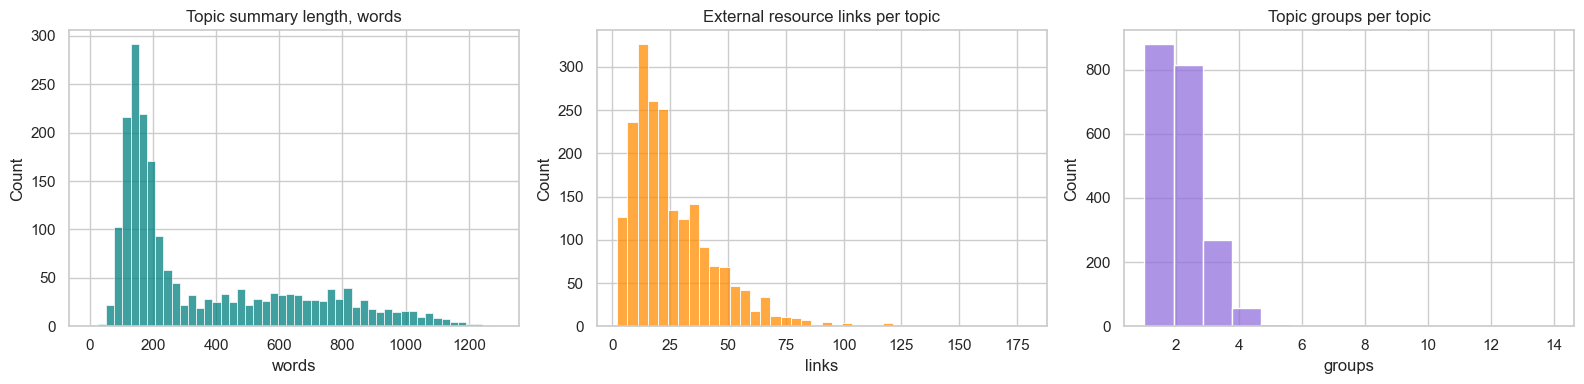

,word_len,char_len,n_sites,n_groups,n_mesh
count,2033.0,2033.0,2033.0,2033.0,2033.0
mean,362.9,2212.6,26.0,1.8,0.7
std,289.4,1773.7,18.7,0.9,0.9
min,0.0,0.0,2.0,1.0,0.0
25%,145.0,880.0,13.0,1.0,0.0
50%,206.0,1254.0,21.0,2.0,0.0
75%,575.0,3467.0,35.0,2.0,1.0
max,1295.0,8201.0,179.0,14.0,6.0


In [21]:
# Shape of the topic table: summary length, how many external links a topic
# points to, and how many topic groups it belongs to.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(topics['word_len'], bins=50, ax=axes[0], color='teal')
axes[0].set_title('Topic summary length, words')
axes[0].set_xlabel('words')

sns.histplot(topics['n_sites'], bins=40, ax=axes[1], color='darkorange')
axes[1].set_title('External resource links per topic')
axes[1].set_xlabel('links')

sns.histplot(topics['n_groups'], bins=14, ax=axes[2], color='mediumpurple')
axes[2].set_title('Topic groups per topic')
axes[2].set_xlabel('groups')

plt.tight_layout()
plt.show()

# The same columns as numbers.
topics[['word_len', 'char_len', 'n_sites', 'n_groups', 'n_mesh']].describe().round(1)


In [22]:
# Missingness in the glossary table. The definitions are complete; some
# reference links are not.

dp.missingness(definitions)


,missing,missing_pct,blank_or_empty
url,0,0.0,33


In [23]:
# The same term is defined in more than one of the five glossary files, so the
# definition text repeats.
#
# keep=False keeps every row in a repeat group, not only the extra copies.

duplicate_definitions = definitions[definitions.duplicated(subset=['text'], keep=False)]
duplicate_definitions = duplicate_definitions.sort_values('text')

print('definition rows                         :', len(definitions))
print('rows whose definition text is not unique:', len(duplicate_definitions))
print()

duplicate_definitions[['collection', 'title', 'word_len']].head(16).to_string(index=False)


definition rows                         : 97
rows whose definition text is not unique: 23



'              collection                               title  word_len\n     vitaminsdefinitions                 Dietary Supplements        47\n    nutritiondefinitions                 Dietary Supplements        47\n     mineralsdefinitions                 Dietary Supplements        47\n     vitaminsdefinitions                        Antioxidants        54\n     mineralsdefinitions                        Antioxidants        54\n      fitnessdefinitions                     Body Mass Index        47\ngeneralhealthdefinitions                     Body Mass Index        47\n    nutritiondefinitions                        Electrolytes        26\n     mineralsdefinitions                        Electrolytes        26\n      fitnessdefinitions                          Heart Rate        40\ngeneralhealthdefinitions                          Heart Rate        40\n     mineralsdefinitions    Multivitamin/Mineral Supplements        50\n     vitaminsdefinitions    Multivitamin/Mineral Supplements   

MedlinePlus is the opposite of MedQuAD in almost every respect that matters. One topic out of 2,033 is missing its summary, and that is the only gap. The shape is close to ideal, with a median of 206 words, a mean of 363, and a maximum of 1,295, so most topics need no splitting at all. And it is already written in plain language, which is the whole reason it is the Simplifier's retrieval target rather than a patient-tone evaluation set.

The `language` attribute is the one filter it needs, and that filter removes half the file. Of the 2,033 topics, 1,016 are not English. They are translations of topics that also exist in English, so they add no medical content, and indexing them would only put a Spanish passage into an English retrieval pool. The attribute matters again for a Spanish version later, since it is what would let such a pipeline find its own grounding text.

The glossary is small and useful in a specific way. It holds 97 terms across five topic files, with a median definition of 46 words, short enough to paste into a prompt without displacing anything else. The catch is that 23 of those 97 rows share their definition text with another row, because the same term is defined in more than one of the five files. Those need deduplicating before indexing, for the same reason the MedQuAD repeats do.

## Overlap between the two datasets

Before either dataset goes into an index, one question matters. How much do MedQuAD and MedlinePlus already contain each other?

In [24]:
# How much do the two datasets already contain each other?
#
# Everything is lowercased and stripped of edge spaces first, so that
# "Diabetes" and "diabetes " count as the same term.

# Every condition MedQuAD writes about. The 14 rows with an empty focus are
# left out, because an empty string is not a condition and would otherwise be
# counted as one more term.
medquad_terms = set(usable.loc[usable['focus'] != '', 'focus'].str.lower().str.strip())

# Every topic title MedlinePlus uses.
medlineplus_titles = set(topics['title'].str.lower().str.strip())

# Every alternative name MedlinePlus gives for a topic. There is one list of
# names per topic, so the two loops below walk the topics and then the names.
medlineplus_aliases = set()
for names in topics['also_called']:
    for name in names:
        medlineplus_aliases.add(name.lower().strip())

# On two sets, & gives the items that appear in both, and | gives the items
# that appear in either one.
title_matches = medquad_terms & medlineplus_titles
any_name_matches = medquad_terms & (medlineplus_titles | medlineplus_aliases)

print('MedQuAD focus terms                  :', len(medquad_terms))
print('MedlinePlus topic titles             :', len(medlineplus_titles))
print('focus terms matching a topic title   :', len(title_matches))
print('focus terms matching a title or alias:', len(any_name_matches))

# Zoom in on the one collection that was built from these very pages.
mplus_qa = usable[usable['collection'] == '4_MPlus_Health_Topics_QA']
focus_is_a_topic_title = mplus_qa['focus'].str.lower().str.strip().isin(medlineplus_titles)

print()
print('4_MPlus_Health_Topics_QA rows        :', len(mplus_qa))
print('  of those, focus is a topic title  :', int(focus_is_a_topic_title.sum()))

# Finally check the text itself, not just the names. An answer that is
# byte-identical to a topic summary is a pure duplicate.
medlineplus_texts = set(topics['text'].str.strip())
answers_matching_topic_text = usable['answer'].str.strip().isin(medlineplus_texts)

print()
print('MedQuAD answers byte-identical to a MedlinePlus topic summary:',
      int(answers_matching_topic_text.sum()))

MedQuAD focus terms                  : 4745
MedlinePlus topic titles             : 1982
focus terms matching a topic title   : 914
focus terms matching a title or alias: 975

4_MPlus_Health_Topics_QA rows        : 981
  of those, focus is a topic title  : 907

MedQuAD answers byte-identical to a MedlinePlus topic summary: 42


The overlap is larger than I expected, and it splits into two levels.

At the entity level, 914 of the 4,745 usable MedQuAD focus terms exactly match a MedlinePlus topic title, 19%, and the alias check pushes that to 975 terms, 21%, once MedlinePlus `also-called` names are counted. Some overlap was inevitable, since the four MedlinePlus-derived MedQuAD collections were built from these very pages. The sharper number is that 907 of the 981 rows in `4_MPlus_Health_Topics_QA` are a MedlinePlus topic, so that collection is largely a second copy of content held in better shape elsewhere.

At the text level the overlap is smaller but real, and this is the check that matters most. 42 MedQuAD answers are byte-identical to a MedlinePlus topic summary, and all 42 sit in that same collection-4 group. Those are pure duplicates and should be dropped rather than embedded twice.

Everything else is a near match rather than an exact one, which is the harder case. If both datasets go into the index undifferentiated, a query about one condition draws back passages about the same condition from two sources, and the Simplifier gets the same fact twice instead of two facts once. An exact-match filter will not catch that. The fix is a source tag on every indexed document plus a per-source cap on how many passages one query may return, so the two datasets corroborate each other instead of competing. Both are already in the shared schema below.

The practical reading is that MedlinePlus holds the better copy of this shared content, so collection 4 is the part of MedQuAD with the least to add.

## One flattened schema for retrieval


In [25]:
# Both datasets are flattened into the same 10-column "retrieval document"
# shape, so a single index can hold both. The two conversion functions live in
# dataset_profile.py and are the only place that mapping is written down.
#
# MedQuAD is restricted to the usable rows and MedlinePlus to the English
# topics, so no unusable slice reaches the index.

medquad_documents = dp.to_retrieval_docs_medquad(usable)
english_topics = topics[topics['is_english']]
medlineplus_documents = dp.to_retrieval_docs_medlineplus(english_topics, definitions)

# Stack the two tables into one. ignore_index=True renumbers the rows from 0
# so the two original indexes do not clash.
retrieval_documents = pd.concat(
    [medquad_documents, medlineplus_documents],
    ignore_index=True,
)

# One summary row per source dataset. Each line inside agg() names a new
# column and the calculation that fills it.
summary = retrieval_documents.groupby('source_dataset').agg(
    documents=('doc_uid', 'size'),              # how many rows
    unique_documents=('doc_uid', 'nunique'),    # how many distinct keys
    median_words=('word_len', 'median'),
    max_words=('word_len', 'max'),
    median_chars=('char_len', 'median'),
)

print('total retrieval documents:', f'{len(retrieval_documents):,}')
summary


total retrieval documents: 17,537


,documents,unique_documents,median_words,max_words,median_chars
source_dataset,,,,,
medlineplus_definitions,97,97,46.0,141,256.0
medlineplus_topics,1017,1017,193.0,1225,1138.0
medquad,16423,16389,146.0,4289,924.0


In [26]:
# The same ten columns for every source, which is the whole point of the
# flattening step.

print('shared columns:', list(retrieval_documents.columns))
retrieval_documents.head(4)


shared columns: ['doc_uid', 'source_dataset', 'collection', 'title', 'section', 'text', 'url', 'language', 'char_len', 'word_len']


,doc_uid,source_dataset,collection,title,section,text,url,language,char_len,word_len
0,medquad/1_CancerGov_QA/0000001_1-1,medquad,1_CancerGov_QA,Adult Acute Lymphoblastic Leukemia,information,What is (are) Adult Acute Lymphoblastic Leukemia ?\nKey Points - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which t...,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,English,2733,444
1,medquad/1_CancerGov_QA/0000001_1-2,medquad,1_CancerGov_QA,Adult Acute Lymphoblastic Leukemia,symptoms,"What are the symptoms of Adult Acute Lymphoblastic Leukemia ?\nSigns and symptoms of adult ALL include fever, feeling tired, and easy br...",https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,English,779,137
2,medquad/1_CancerGov_QA/0000001_1-3,medquad,1_CancerGov_QA,Adult Acute Lymphoblastic Leukemia,exams and tests,How to diagnose Adult Acute Lymphoblastic Leukemia ?\nTests that examine the blood and bone marrow are used to detect (find) and diagnos...,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,English,2534,453
3,medquad/1_CancerGov_QA/0000001_1-4,medquad,1_CancerGov_QA,Adult Acute Lymphoblastic Leukemia,outlook,What is the outlook for Adult Acute Lymphoblastic Leukemia ?\nCertain factors affect prognosis (chance of recovery) and treatment option...,https://www.cancer.gov/types/leukemia/patient/adult-all-treatment-pdq,English,469,76


In [27]:
# Write the result to disk as JSONL: one JSON object per line, one document per
# line. This is the file the index will read.
#
# force_ascii=False keeps accented characters as characters instead of turning
# them into \u escape codes.
#
# The file goes straight into data/, next to the raw datasets, so every path in
# the project points at the same folder. No subfolder is created.

output_path = dp.DATA_DIR / 'retrieval_docs_medquad_medlineplus.jsonl'

retrieval_documents.to_json(
    output_path,
    orient='records',      # one record per line
    lines=True,
    force_ascii=False,
)

size_mb = output_path.stat().st_size / 1e6
print(f'wrote {len(retrieval_documents):,} documents to {output_path} ({size_mb:.1f} MB)')
print('data/ is git-ignored, so this intermediate never reaches the repository.')

wrote 17,537 documents to C:\Users\hoang\Subdisk\school\UIC\BTT\Fall AI Studio\Google-2E\data\retrieval_docs_medquad_medlineplus.jsonl (29.1 MB)
data/ is git-ignored, so this intermediate never reaches the repository.


### How the XML becomes usable

The XML is not a problem to work around. It is the reason these two datasets are the most trustworthy text in the project, and three steps turn it into something usable.

**Parse.** XML is nested by design. MedQuAD hides a QAPair inside a QAPairs block inside a Document, and the meaning lives in attributes (`qid`, `qtype`, `pid`) rather than in the text. MedlinePlus hides a topic summary inside escaped HTML inside a `full-summary` element, alongside groups, mesh headings, and links. None of that survives a flat read, which is why `dataset_profile.py` parses both with ElementTree and normalises the whitespace and HTML the pretty-printer left behind.

**Flatten into one schema.** Both datasets project into the same ten columns:

| Column | Type | Meaning |
| --- | --- | --- |
| `doc_uid` | id | Stable key. Never a feature. |
| `source_dataset` | nominal | `medquad`, `medlineplus_topics`, or `medlineplus_definitions`. |
| `collection` | nominal | The MedQuAD folder or the glossary file, kept for provenance. |
| `title` | text | The focus entity for MedQuAD, the topic title for MedlinePlus. |
| `section` | nominal | The question type, or a fixed label such as `topic-summary`. |
| `text` | text | The retrievable passage. |
| `url` | text | Source link, which is what makes grounding checkable. |
| `language` | nominal | English, with the attribute preserved so Spanish can be added later. |
| `char_len`, `word_len` | integer | Length, which drives the chunking decision. |

Once both datasets are in that shape, the index code, the retrieval smoke test, and the Simplifier's retrieval tool do not need to know which dataset a passage came from. One schema means one indexing path, and the two functions that do it are `to_retrieval_docs_medquad` and `to_retrieval_docs_medlineplus`.

**Keep the provenance.** The `url` and `collection` columns are not decoration. The Verifier has to attribute a claim to a source, and MedQuAD's XML carries the NLM page URL for every pair. That is the difference between a system that claims an explanation is faithful and one that can show where each fact came from.

The combined dataset is the size printed in the summary table above. It is written to `data/` alongside the raw datasets, in a folder that is git-ignored, so the file stays local.

## Data profile summary

**Column types.** 23 columns for MedQuAD, 23 for MedlinePlus topics, 13 for the glossary. Five columns are keys rather than features: `qa_uid`, `doc_id`, and `qid` are identifiers, `pid` is a position inside a document, and `topic_id` keys the MedlinePlus side. Nominal: `collection`, `source`, `focus_category`, `qtype`, `language`, `semantic_group`, and the multi-value lists on the MedlinePlus side, `also_called`, `groups`, `mesh`, `other_language`. Free text: `focus`, `title`, `question`, `answer`, `text`, `url`, `meta_desc`, `primary_institute`. Integer: `answer_chars`, `answer_words`, `question_words`, `n_synonyms`, `n_sites`, `n_see_reference`. Ordinal or small-integer counts: `n_cuis`, `n_semantic_types`, `n_groups`, `n_mesh`. Binary flags: `answer_missing`, `has_umls`, `text_missing`, `is_english`.

**Missingness.** MedQuAD has 31,034 empty answers, 65% of the dataset, and 31,029 of those come from the three collections MedQuAD stripped for copyright. The pattern is structural, so the treatment is exclusion rather than imputation, and every affected row keeps a URL that makes the decision reversible. `focus_category` is absent for 15,447 pairs and the UMLS block for 16,040, in both cases because of collection layout rather than data loss. MedlinePlus topics are essentially complete, one empty summary out of 2,033. The glossary has no missing definitions, but 33 of its 97 terms carry no reference URL.

**Balance.** Not applicable. Neither dataset has a label, so there is no class to be imbalanced.

**Outliers.** The IQR fence at k = 2 flags 629 rows, 3.8% of the answer-bearing pairs, from an upper bound of 614 words. That share is too high to delete, and the cause is a long right tail inflating the fence rather than a cluster of errors. So the long entries stay, and they get chunked instead of deleted or winsorized. A 1% cut would land at 1,278 words and separate 165 rows.

**Redundancy.** `answer_words` and `answer_chars` are near-redundant, so only one belongs in any feature set. `question_words` is weakly correlated with answer length on Pearson, so mutual information is what decides whether it carries signal. Across the two datasets, 19% of usable MedQuAD focus terms reappear as a MedlinePlus topic title, 21% with aliases, and 42 answers are byte-identical to a MedlinePlus summary. That duplication is part literal and part conceptual, so it needs an exact-match drop and a source tag.

**Identifiers.** `(collection, qid)` is almost unique, with 34 rows too many, all in `1_CancerGov_QA`. CancerGov ships one topic as a parent file plus a file per subtype, all sharing an `id` and reusing the parent's question numbers, so neither `qid` nor `doc_id` separates them: the key has to include the file. The projected dataset shows why it cannot wait: 16,423 MedQuAD documents come out against 16,389 unique keys. Answer text repeats in 4.16% of non-empty rows and collapses to 85 distinct passages, none crossing a collection, though one is reused 348 times. In the glossary, 23 of 97 rows share their definition text with another row.

**Content spot check.** The XML export dropped non-ASCII characters, so 18 answers carry a mangled `Espaol` where the source read `Español`, all of them in NHLBI, and 161 answers write a double hyphen where a dash used to be. One condition can also produce many passages. A single focus, Heart Failure, is covered by 20 rows across 8 question types, which means near-duplicates will compete for the same retrieval slots.

**What each dataset is usable for.** MedQuAD gives consumer-tone reference text and retrieval grounding for condition explanations, with the caveats that only 35% of it carries answers, that two of its three biggest collections are unusable, and that its usable text skews to rare disease. MedlinePlus topics are the primary plain-language retrieval base: complete, already at a patient reading level, and the better copy of the content the two datasets share. The MedlinePlus glossary supplies short definitional text to inject when a clinical term has to be substituted rather than dropped.

## Decisions before indexing

1. Extend the join key with the file name in `dataset_profile.py` before anything is indexed, so the 34 repeated keys cannot propagate into the index. `doc_id` does not separate them; only `collection + file + qid` is unique.
2. Deduplicate on exact answer text before embedding. That removes the 85 repeated passages, including the one reused 348 times, and the 42 duplicates of MedlinePlus summaries.
3. Tag every document with `source_dataset` and cap results per source, so MedQuAD and MedlinePlus corroborate each other instead of competing.
4. Chunk the long tail of MedQuAD answers on sentence boundaries, using the 193-word median of the English MedlinePlus topics, which is what the index actually holds, as the target width.
5. Fix the encoding artifacts in the shared parser rather than in a prompt: restore accented characters, and normalise the ` -- ` patterns the export produced.
6. Run the same profile on PLABA and the Synthea sample, reusing `dataset_profile.py` instead of writing a second script.
7. Share this profile alongside the MedAESQA profile so the Simplifier and Verifier work from the same view of which dataset grounds which claim.

The second read path for the four NINDS files is already in `dataset_profile.py`. The parser recognises the older lowercase schema and rewrites the element and attribute names in memory, which brings those 16 pairs back to 47,457 and matches MedQuAD's own readme. The same pass drops blank annotation values, so the placeholder `<cui></cui>` element in those files no longer counts as a machine-readable concept.